In [1]:
"""
Sample code that loads cancer risk data and plots a simple clustering

The CSV files for the loaded risk data have their FIPS codes stored in 
ascending order. Since FIPS codes are roughly ordered based on the names 
of their state names, the result clustering follows these names.
"""

import math
import pandas as pd
import matplotlib as mpl
import project10_provided as provided

In [2]:
############################################################
# Code to create sequential clustering

def sequential_clustering(singleton_list, num_clusters):
    """
    Input: List singleton_list of clusters, integer, num_clusters
    
    Output: List of clusters formed by partitioning the list
    into clusters based on its ordering
    
    NOTE: Returns num_clusters or num_clusters + 1 final clusters
    """
    
    cluster_list = []
    cluster_idx = 0
    total_clusters = len(singleton_list)
    cluster_size = float(total_clusters)  / num_clusters
    
    for cluster_idx in range(len(singleton_list)):
        new_cluster = singleton_list[cluster_idx]
        if math.floor(cluster_idx / cluster_size) != \
           math.floor((cluster_idx - 1) / cluster_size):
            cluster_list.append(new_cluster)
        else:
            cluster_list[-1] = cluster_list[-1].merge_clusters(new_cluster)
            
    return cluster_list
                

Displaying 15 sequential clusters


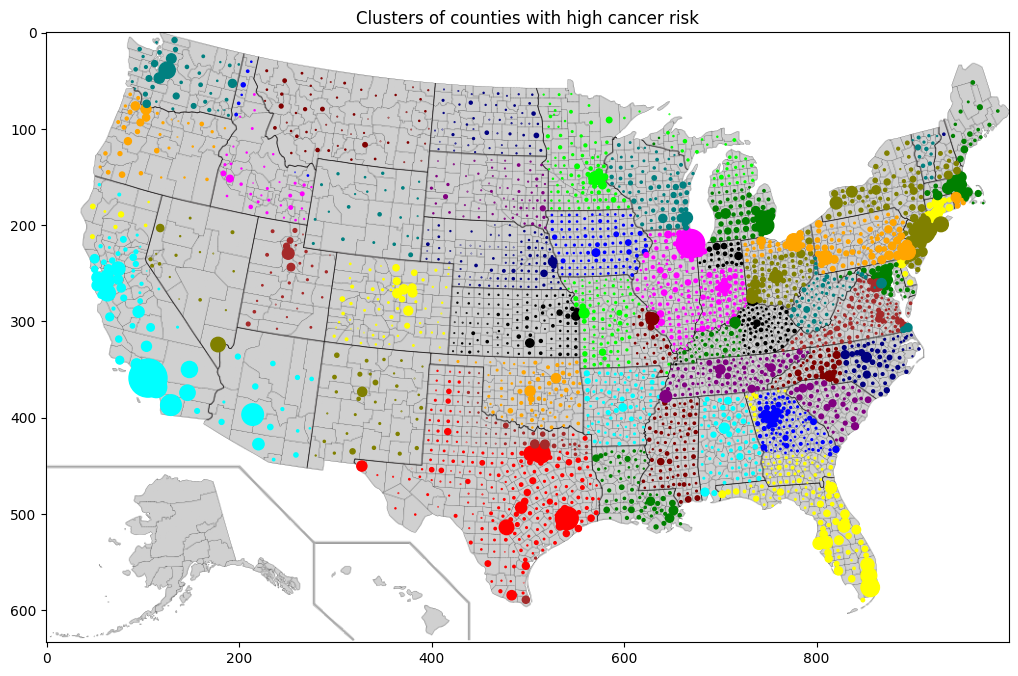

In [3]:
#####################################################################
# Code to load cancer data, compute a clustering and visualize the results


def test_sequential_clustering():
    """ Test sequential_clustering() """
    
    # Load in cancer risk data - ordered by FIPS code
    risk_file = provided.DATA_3108
    risk_frame = provided.risk_csv_to_dataframe(risk_file)
    singleton_clusters = provided.dataframe_to_singleton_clusters(risk_frame)
   
    cluster_list = sequential_clustering(singleton_clusters, 15)	
    print("Displaying", len(cluster_list), "sequential clusters")
    provided.plot_clusters_members(cluster_list, risk_frame)


# Default DPI for notebook graphics is 80, override for higher resolution images
mpl.rcParams['figure.dpi']= 100

test_sequential_clustering()